# Local growth-curve attribution — plot and subcompartment scale

This notebook asks the revised question from the Stage 2 handover:

**Which environmental conditions are associated with stable differences between growth curves in different
areas of Aberfoyle?**

It does not use a residual from the forest-wide Chapman–Richards curve as its target. Each plot
gets a fixed-shape local curve. The curve's `y_max` is fitted from that plot's own repeated
Top Height observations. The reference is the plot's static Forest Research yield-class (`yldc`)
curve. The quantity to explain is:

`local_y_max_difference = fitted local y_max - yldc-implied y_max`.

A positive value means the plot's repeated observations support a higher curve than its recorded
yield class. A negative value means they support a lower curve. The aim is to explain variation
in this difference, not to force it towards zero. This is not a deviation from an
average fitted to the same forest.

Only `y_max` is free. Each plot keeps its recorded `p4` and `p5`. Four to six observations do not
reliably identify three free curve parameters independently. The notebook audits the consequence
of that fixed-shape assumption before testing environmental attribution.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from scipy.stats import chi2_contingency, spearmanr

notebook_directory = Path.cwd().resolve()
project_root = next(folder for folder in [notebook_directory, *notebook_directory.parents] if (folder / 'README.md').exists())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from models.common.metrics import compute_metrics
from models.common.splits import SPATIAL_BLOCK_COL, SPATIAL_BUFFER_METRES, spatial_block_split
from models.elasticnet_environmental.elasticnet_environmental import (
    CATEGORICAL_COLUMNS, drop_rows_with_missing_features,
    fit_with_columns as elasticnet_fit, predict_with_columns as elasticnet_predict,
)
from models.growth_curve_attribution.data import load_filtered_growth_curve_table
from models.growth_curve_attribution.disturbance_checks import (
    classify_structural_change_intervals, derive_structural_change_intervals,
    fit_all_years_and_compute_residuals,
)
from models.growth_curve_attribution.temporal_stability_check import fit_y_max_per_plot
from models.xgb_environmental.data import load_environmental_features
from models.xgb_environmental.grouped_analysis import (
    CATEGORY_GROUPS, category_morans_i_before_after, cross_category_correlations,
    grouped_permutation_importance, per_variable_refit_ablation,
)
from models.xgb_environmental.xgb_environmental import (
    ALL_FEATURE_COLUMNS, fit_with_columns as xgb_fit, predict_with_columns as xgb_predict,
)

COHORT = '4survey'
TARGET = 'local_y_max_difference'
EXTRA_CANDIDATE_GROUPS = {
    'wind': [
        'gwa_weibull_a_10m', 'gwa_weibull_k_10m', 'gwa_wind_p95_10m',
        'gwa_prob_above_critical_10m', 'midas_max_gust', 'midas_wind_p95',
        'gwa_wind_speed_50m', 'gwa_weibull_a_50m', 'gwa_weibull_k_50m',
        'gwa_wind_p95_50m', 'gwa_prob_above_critical_50m',
        'midas_storm_count', 'midas_hours_above_critical',
        'midas_cumulative_wind_excess', 'midas_time_since_last_major_storm',
    ],
    'climate': [
        'haduk_consecutive_dry_days', 'haduk_dry_spell_count',
        'haduk_cumulative_rain_deficit', 'haduk_spei3', 'haduk_spei6', 'haduk_spei12',
    ],
    'terrain': [
        'tpi_250m', 'tpi_500m', 'local_relief_500m', 'terrain_openness', 'relative_elevation_500m',
        'flow_accumulation', 'height_above_nearest_drainage', 'upwind_fetch',
    ],
    'soil_site': [
        'soil_depth', 'peat_depth', 'soil_organic_carbon',
        'available_water_capacity', 'depth_to_bedrock',
    ],
}
LOCAL_CATEGORY_GROUPS = {category:list(columns) for category, columns in CATEGORY_GROUPS.items()}
for category, columns in EXTRA_CANDIDATE_GROUPS.items():
    LOCAL_CATEGORY_GROUPS[category] = LOCAL_CATEGORY_GROUPS.get(category, []) + columns
pd.set_option('display.max_columns', 80)
print('project_root:', project_root)


project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


## 1. Construct one local curve difference per plot

The curve difference uses `Top_Height95`, because that is the height convention used by the yldc
curve. It does not use the row-level `GYCspec95` value. `GYCspec95` is reconstructed from the
same row's observed height and age, which would make it circular as a predictor or reference.


In [2]:
growth_rows = load_filtered_growth_curve_table(COHORT).dropna(subset=['y_max_yldc']).copy()
fitted_y_max = fit_y_max_per_plot(growth_rows)

plot_static = (
    growth_rows.sort_values('LiDAR_year')
    .groupby('identification', as_index=False)
    .first()[['identification', 'blk', 'cpmt', 'scpt', 'x', 'y', 'yldc', 'p1', 'p2', 'p3', 'p4', 'p5', 'y_max_yldc']]
)
curve_targets = plot_static.merge(fitted_y_max, on='identification', how='inner')
curve_targets[TARGET] = curve_targets['y_max_fit'] - curve_targets['y_max_yldc']

print(f"Rows used: {len(growth_rows):,}; local curves: {len(curve_targets):,}")
display(curve_targets[['y_max_fit', 'y_max_yldc', TARGET, 'n_fitting_points']].describe())
print('Recorded p1-p5 combinations:', growth_rows[['p1','p2','p3','p4','p5']].drop_duplicates().shape[0])


  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448
Rows used: 227,364; local curves: 56,841


,y_max_fit,y_max_yldc,local_y_max_difference,n_fitting_points
count,56841.000000,56841.000000,56841.000000,56841.0
mean,41.512284,38.522062,2.990222,4.0
std,12.408807,8.454267,11.270673,0.0
min,4.355151,15.083864,-64.004002,4.0
25%,33.395002,32.770448,-3.820738,4.0
50%,43.019419,38.665976,3.500631,4.0
75%,50.194926,46.387482,10.279863,4.0
max,116.176127,79.344714,60.663638,4.0


Recorded p1-p5 combinations: 6


## 2. Curve-quality gate

A local parameter is not a trustworthy attribution target merely because it can be calculated.
The checks below identify systematic shape error and extreme trajectories. They flag plots; they
do not delete them. Any exclusion rule must be fixed using training data and a documented data
quality reason.


  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


,count,mean,std
LiDAR_year,,,
2008,56841,-0.362017,1.941164
2012,56841,-0.190985,1.449669
2021,56841,-0.025093,1.250116
2023,56841,0.451608,1.979385


Top 1% residual-range flag begins at 17.82 m; this is a review flag, not an exclusion.


,identification,cpmt,scpt,curve_rmse,residual_range,local_y_max_difference
42557,330689,2163,H,18.971628,47.199552,15.832748
42568,330700,2163,H,17.529185,42.363918,13.283315
42562,330694,2163,H,17.465623,42.181696,15.849411
1301,51948,1048,F,15.601503,37.793547,1.327308
1277,51917,1034,I,15.640799,36.959300,4.646521
42566,330698,2163,H,15.417366,36.940158,15.296601
32846,239840,1085,C,17.488115,36.801608,-3.978656
41740,318400,1053,B,17.487996,36.680004,-5.373703
52534,361540,2170,A,15.444944,36.650153,-10.648155
56169,372203,1057,C,15.254756,36.402688,8.191470


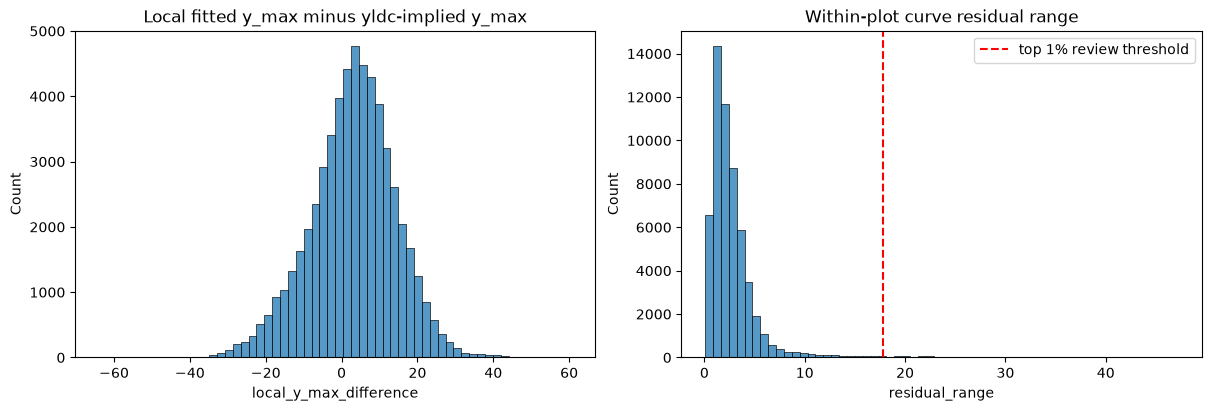

In [3]:
curve_rows = fit_all_years_and_compute_residuals(COHORT)
curve_fit_quality = (
    curve_rows.groupby('identification')
    .agg(curve_rmse=('residual', lambda values: float(np.sqrt(np.mean(np.square(values))))),
         residual_range=('residual', lambda values: float(values.max() - values.min())),
         first_age=('Age', 'min'), last_age=('Age', 'max'))
    .reset_index()
)
curve_targets = curve_targets.merge(curve_fit_quality, on='identification', how='left')
tail_cutoff = curve_targets['residual_range'].quantile(0.99)
curve_targets['extreme_trajectory_flag'] = curve_targets['residual_range'] >= tail_cutoff

by_year = curve_rows.groupby('LiDAR_year')['residual'].agg(['count','mean','std'])
display(by_year)
print(f"Top 1% residual-range flag begins at {tail_cutoff:.2f} m; this is a review flag, not an exclusion.")
display(curve_targets.nlargest(15, 'residual_range')[['identification','cpmt','scpt','curve_rmse','residual_range',TARGET]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
sns.histplot(curve_targets[TARGET], bins=60, ax=axes[0])
axes[0].set_title('Local fitted y_max minus yldc-implied y_max')
sns.histplot(curve_targets['residual_range'], bins=60, ax=axes[1])
axes[1].axvline(tail_cutoff, color='red', linestyle='--', label='top 1% review threshold')
axes[1].set_title('Within-plot curve residual range')
axes[1].legend()
plt.show()


## 3. Map the local curve difference and curve-quality problems

These maps replace the old global-residual map. They show where local fitted curves sit above or
below their recorded yldc curves, where the fixed-shape curve fits poorly, and whether extreme
trajectories form spatial clusters. A spatial pattern is evidence of structure, not evidence that
a particular environmental variable caused it.


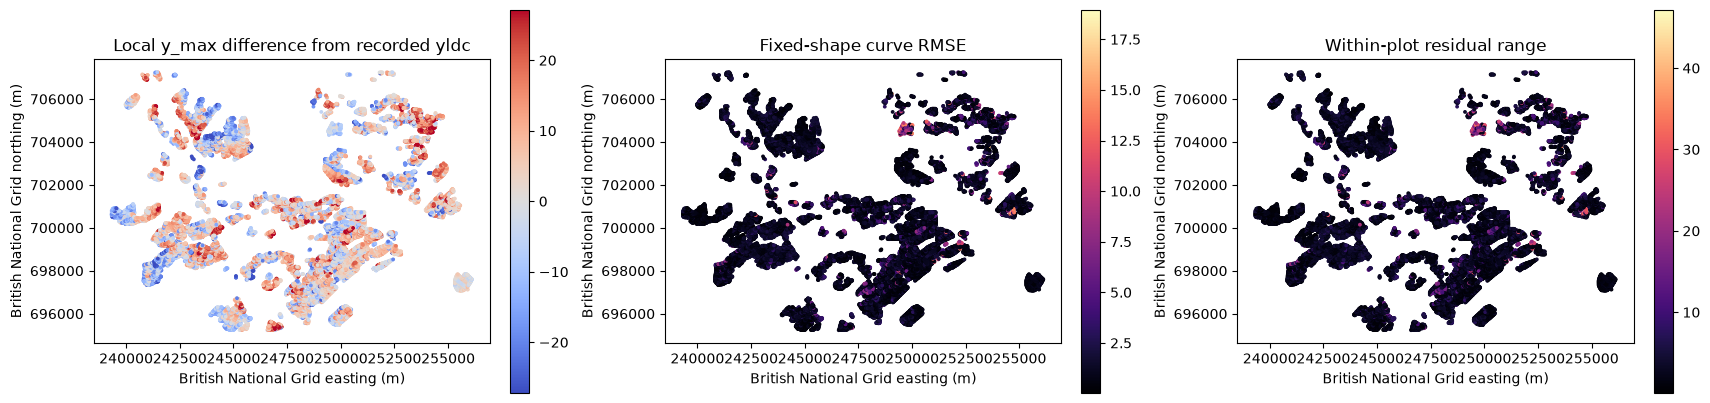

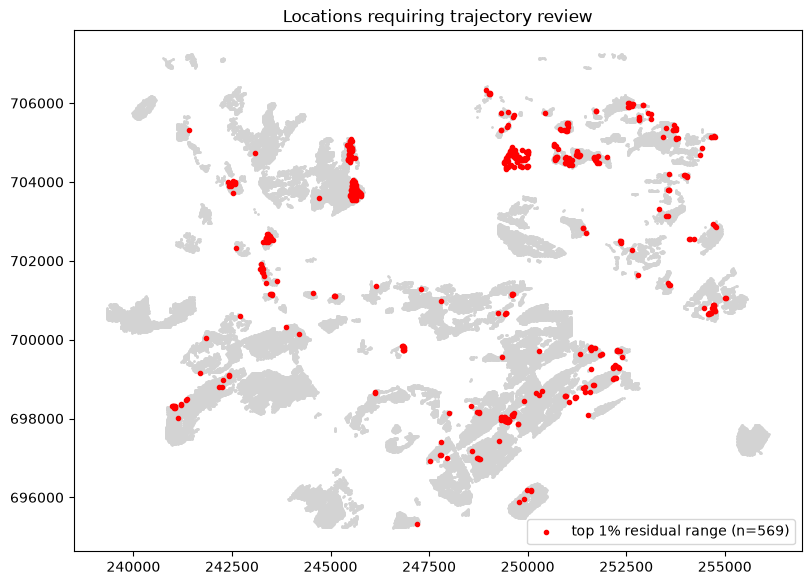

In [4]:
def plot_spatial_values(ax, table, value_column, title, cmap='coolwarm', symmetric=False):
    values = table[value_column]
    colour_limit = np.nanquantile(np.abs(values), 0.98) if symmetric else None
    kwargs = {'vmin':-colour_limit, 'vmax':colour_limit} if symmetric else {}
    plotted = ax.scatter(table['x'], table['y'], c=values, s=3, cmap=cmap, rasterized=True, **kwargs)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlabel('British National Grid easting (m)')
    ax.set_ylabel('British National Grid northing (m)')
    return plotted

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
objects = [
    plot_spatial_values(axes[0], curve_targets, TARGET, 'Local y_max difference from recorded yldc', symmetric=True),
    plot_spatial_values(axes[1], curve_targets, 'curve_rmse', 'Fixed-shape curve RMSE', cmap='magma'),
    plot_spatial_values(axes[2], curve_targets, 'residual_range', 'Within-plot residual range', cmap='magma'),
]
for ax, plotted in zip(axes, objects):
    fig.colorbar(plotted, ax=ax, shrink=.78)
plt.show()

flagged = curve_targets[curve_targets['extreme_trajectory_flag']]
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
ax.scatter(curve_targets['x'], curve_targets['y'], s=1, color='lightgrey', rasterized=True)
ax.scatter(flagged['x'], flagged['y'], s=9, color='red', label=f"top 1% residual range (n={len(flagged):,})")
ax.set_aspect('equal')
ax.set_title('Locations requiring trajectory review')
ax.legend()
plt.show()


## 4. Diagnose height collapses using canopy and standing volume

A height collapse is not one phenomenon. The cells below derive consecutive-survey fractional
changes in top height, canopy cover and standing volume. They first plot the measurements rather
than assuming that round-number classes are natural groups.

The provisional labels are diagnostic hypotheses:

- `clearfell_like`: height, canopy and volume each fall by at least 70%;
- `measurement_inconsistent`: height falls by at least 25%, canopy falls by at most 10%, and volume does not fall;
- `ambiguous_disturbance`: another height collapse, including possible partial windthrow;
- `no_height_collapse`: the interval does not meet the height threshold.

These names do not establish cause. Clearfell records, storm exposure or source-LiDAR checks are
needed for that. The raw changes and flags remain available so threshold sensitivity can be shown.


In [5]:
structural_intervals = derive_structural_change_intervals(growth_rows)
structural_intervals = classify_structural_change_intervals(structural_intervals)
flagged_ids = set(curve_targets.loc[curve_targets['extreme_trajectory_flag'], 'identification'])
flagged_structural = structural_intervals.loc[structural_intervals['identification'].isin(flagged_ids)].copy()
display(flagged_structural['structural_change_class'].value_counts(dropna=False).rename('intervals').to_frame())
display(flagged_structural.groupby('structural_change_class')[
    ['height_drop_frac','canopy_drop_frac','volume_drop_frac']
].agg(['count','median','min','max']))


,intervals
structural_change_class,
no_height_collapse,1090
ambiguous_disturbance,453
clearfell_like,147
measurement_inconsistent,17


height_drop_frac                                \
                                    count    median       min       max   
structural_change_class                                                   
ambiguous_disturbance                 453  0.713241  0.251440  0.894952   
clearfell_like                        147  0.812740  0.251122  0.928092   
measurement_inconsistent               17  0.576988  0.258017  0.806616   
no_height_collapse                   1090 -0.138290 -8.371038  0.245594   

                         canopy_drop_frac                                  \
                                    count    median         min       max   
structural_change_class                                                     
ambiguous_disturbance                 453  0.383209   -7.572462  0.698630   
clearfell_like                        147  0.908221    0.700320  0.998711   
measurement_inconsistent               17 -7.455666  -16.090237 -2.473060   
no_height_collapse                   1090 -0.048403 -114.063322  0.975454   

                         volume_drop_frac                                   
                                    count    median          min       max  
structural_change_class                                                     
ambiguous_disturbance                 453  0.939827     0.096659  0.998072  
clearfell_like                        147  0.994461     0.844538  0.999995  
measurement_inconsistent               17 -0.940511    -3.996868 -0.148137  
no_height_collapse                   1090 -0.469239 -1393.565803  0.984730

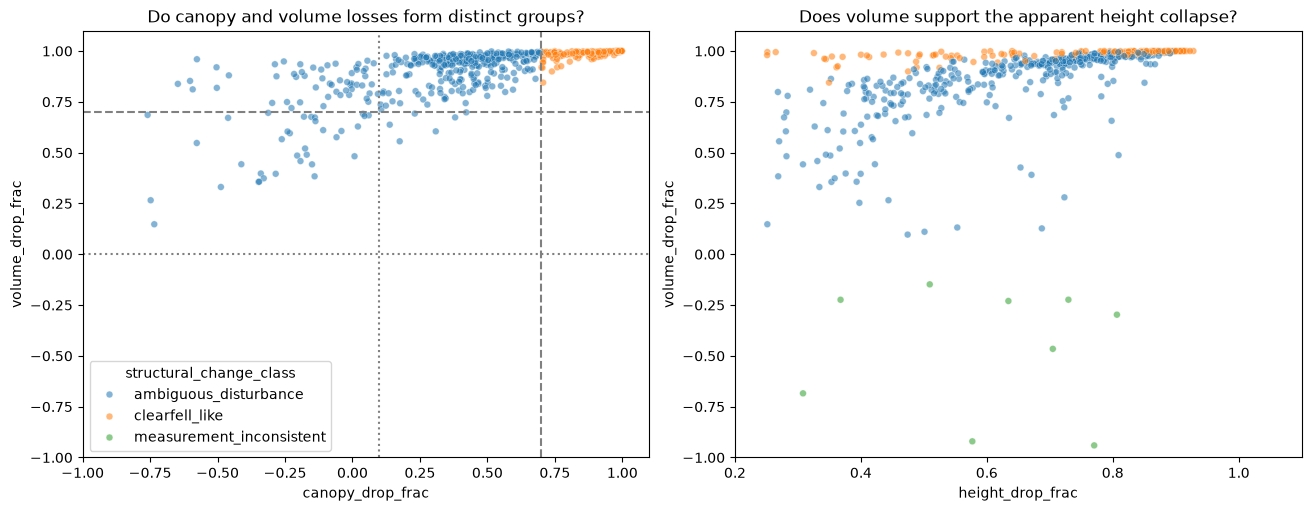

In [6]:
height_collapse_intervals = flagged_structural.loc[flagged_structural['height_collapse_flag']].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
sns.scatterplot(data=height_collapse_intervals, x='canopy_drop_frac', y='volume_drop_frac',
                hue='structural_change_class', alpha=.55, s=24, ax=axes[0])
axes[0].axvline(.70, color='grey', linestyle='--')
axes[0].axhline(.70, color='grey', linestyle='--')
axes[0].axvline(.10, color='grey', linestyle=':')
axes[0].axhline(0, color='grey', linestyle=':')
axes[0].set_title('Do canopy and volume losses form distinct groups?')
axes[0].set_xlim(-1, 1.1); axes[0].set_ylim(-1, 1.1)
sns.scatterplot(data=height_collapse_intervals, x='height_drop_frac', y='volume_drop_frac',
                hue='structural_change_class', alpha=.55, s=24, ax=axes[1], legend=False)
axes[1].set_title('Does volume support the apparent height collapse?')
axes[1].set_xlim(.20, 1.1); axes[1].set_ylim(-1, 1.1)
plt.show()

# One row per flagged plot: retain its largest fractional height loss for maps and audit tables.
worst_change_per_plot = (flagged_structural.sort_values('height_drop_frac', ascending=False)
                         .drop_duplicates('identification'))
curve_targets = curve_targets.merge(
    worst_change_per_plot[['identification','previous_LiDAR_year','LiDAR_year',
        'height_drop_frac','canopy_drop_frac','volume_drop_frac','structural_change_class',
        'joint_structure_collapse_flag','measurement_inconsistent_flag',
        'ambiguous_disturbance_flag']],
    on='identification', how='left', validate='one_to_one'
)


In [7]:
sensitivity_rows = []
for height_threshold in [.20, .25, .30, .40]:
    for joint_threshold in [.60, .70, .80]:
        classified = classify_structural_change_intervals(
            flagged_structural, height_drop_threshold=height_threshold,
            joint_collapse_threshold=joint_threshold, stable_structure_threshold=.10)
        counts = classified['structural_change_class'].value_counts()
        sensitivity_rows.append({
            'height_threshold':height_threshold, 'joint_threshold':joint_threshold,
            **{name:int(counts.get(name, 0)) for name in
               ['clearfell_like','measurement_inconsistent','ambiguous_disturbance','no_height_collapse']}
        })
display(pd.DataFrame(sensitivity_rows))


,height_threshold,joint_threshold,clearfell_like,measurement_inconsistent,ambiguous_disturbance,no_height_collapse
0,0.20,0.6,190,20,423,1074
1,0.20,0.7,149,20,464,1074
2,0.20,0.8,114,20,499,1074
3,0.25,0.6,188,17,412,1090
4,0.25,0.7,147,17,453,1090
5,0.25,0.8,112,17,488,1090
6,0.30,0.6,185,15,403,1104
7,0.30,0.7,144,15,444,1104
8,0.30,0.8,109,15,479,1104
9,0.40,0.6,176,12,380,1139


## 5. Merge validated environmental variables

The old pooled-curve residual columns are deliberately not merged as predictors. Environmental
variables are joined by plot identifier. Categorical soil class IDs remain categorical.


In [8]:
environment = load_environmental_features()
# The environmental export stores time-varying HadUK summaries separately for each cohort.
# Rename only this cohort's columns to the plain names expected by the approved feature list.
cohort_suffix = f'_{COHORT}'
cohort_bases = ['tas_mean','groundfrost_mean','rainfall_mean','tasmax_mean','tasmin_mean','sun_mean','sfcWind_mean']
cohort_rename = {f'{base}{cohort_suffix}':base for base in cohort_bases if f'{base}{cohort_suffix}' in environment.columns}
environment = environment.rename(columns=cohort_rename)

approved_features = [column for column in ALL_FEATURE_COLUMNS if column in environment.columns]
extracted_extra_features = [
    column for columns in EXTRA_CANDIDATE_GROUPS.values() for column in columns
    if column in environment.columns
]
available_features = list(dict.fromkeys(approved_features + extracted_extra_features))
environment_columns = ['identification'] + available_features
local_plots = curve_targets.merge(environment[environment_columns], on='identification', how='left', validate='one_to_one')

missing_summary = local_plots[available_features].isna().mean().sort_values(ascending=False)
display(missing_summary[missing_summary > 0].rename('missing_fraction').to_frame())
print(f"Local curve differences: {len(local_plots):,}; imported model candidates: {len(available_features)}")
print('Extracted new wind/drought/terrain candidates:', extracted_extra_features or 'none yet')


,missing_fraction
soilgrids_ph,0.006932
ceh_textural_composition,0.000651
ceh_pedotope,0.000651
ceh_twi,0.000651
ceh_subsurface_drainage,0.000651


Local curve differences: 56,841; imported model candidates: 49
Extracted new wind/drought/terrain candidates: ['gwa_weibull_a_10m', 'gwa_weibull_k_10m', 'gwa_wind_p95_10m', 'gwa_prob_above_critical_10m', 'gwa_wind_speed_50m', 'gwa_weibull_a_50m', 'gwa_weibull_k_50m', 'gwa_wind_p95_50m', 'gwa_prob_above_critical_50m', 'tpi_250m', 'tpi_500m', 'local_relief_500m']


## 6. Environmental data-quality table and maps

The auxiliary-data notebook remains the source audit for native resolution and extraction. This
section checks the exact rows entering the local-curve analysis. A high plot count does not turn
a 1 km climate grid into plot-resolution data. `n_distinct` makes that limitation visible.


,variable,category,missing_pct,n_distinct,minimum,maximum,std
38,chelsa_bio1_celsius,climate,0.000000,28,6.350000e+00,9.150000,0.619904
41,tas_mean,climate,0.000000,140,5.754355e+00,9.144576,0.637646
42,groundfrost_mean,climate,0.000000,140,8.782457e+00,9.472668,0.179409
39,chelsa_gdd5_degc,climate,0.000000,194,9.065000e+02,1580.800000,156.581358
40,chelsa_bio12_precip_mm,climate,0.000000,247,1.729800e+03,3004.800000,253.287993
36,ceh_subsurface_drainage,soil_site,0.065094,3,1.000000e+00,3.000000,0.807730
37,ceh_textural_composition,soil_site,0.065094,4,1.000000e+00,5.000000,0.388034
34,ceh_pedotope,soil_site,0.065094,7,2.000000e+00,12.000000,0.803531
33,soilgrids_ph,soil_site,0.693162,13,4.000000e+00,5.200000,0.160397
31,dist_to_watercourse,soil_site,0.000000,56836,4.526817e-03,1850.857676,344.695306


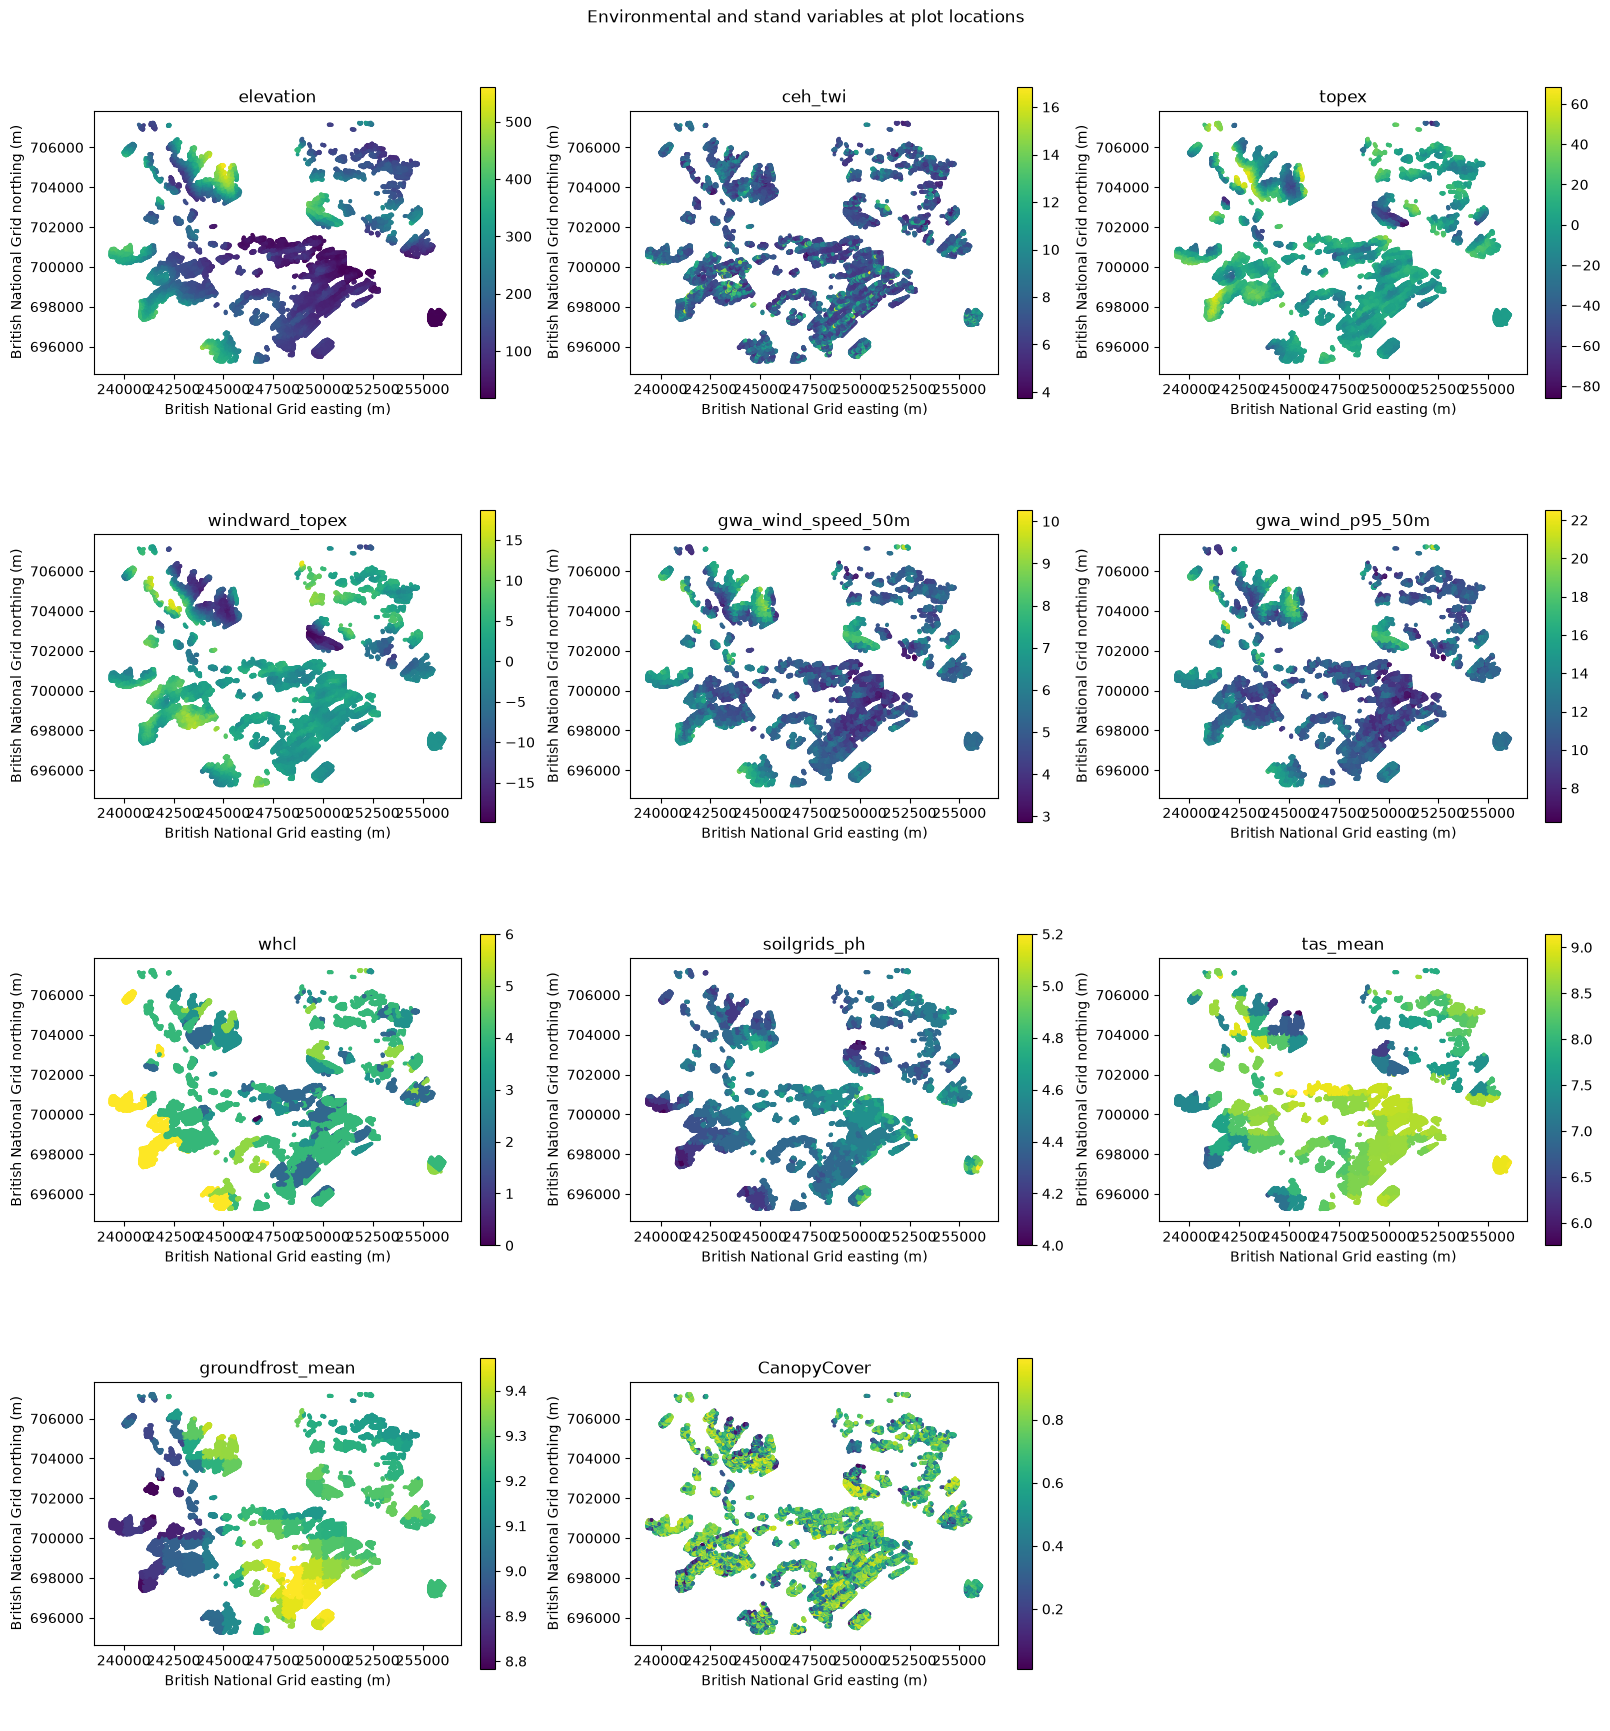

In [9]:
feature_to_category = {column: category for category, columns in LOCAL_CATEGORY_GROUPS.items() for column in columns}
quality_rows = []
for column in available_features:
    values = local_plots[column]
    quality_rows.append({
        'variable':column, 'category':feature_to_category[column],
        'missing_pct':100*values.isna().mean(), 'n_distinct':values.nunique(dropna=True),
        'minimum':values.min(), 'maximum':values.max(), 'std':values.std(),
    })
feature_quality = pd.DataFrame(quality_rows).sort_values(['category','n_distinct'])
display(feature_quality)

map_columns = [column for column in [
    'elevation','ceh_twi','topex','windward_topex','gwa_wind_speed_50m','gwa_wind_p95_50m','whcl',
    'soilgrids_ph','tas_mean','groundfrost_mean','CanopyCover',
] if column in local_plots.columns]
fig, axes = plt.subplots(int(np.ceil(len(map_columns)/3)), 3, figsize=(16, 4.3*np.ceil(len(map_columns)/3)), constrained_layout=True, squeeze=False)
for ax, column in zip(axes.ravel(), map_columns):
    plotted = plot_spatial_values(ax, local_plots, column, column, cmap='viridis')
    fig.colorbar(plotted, ax=ax, shrink=.75)
for ax in axes.ravel()[len(map_columns):]:
    ax.axis('off')
fig.suptitle('Environmental and stand variables at plot locations')
plt.show()


## Data-source and derived-variable register

This table prevents planned variables being mistaken for measured results. `imported` means the
column exists in the current environmental export and enters this notebook. `exported_not_in_model`
means the source was extracted earlier but excluded from the approved feature set. `planned` means
the variable still requires acquisition and validation.

A variable must also match the biological timescale. Long-term wind regime, soil and terrain can
explain a persistent local curve difference. Time since a storm, drought duration and storm counts
belong primarily in an interval-level analysis asking whether the trajectory changed after the
event. They should not be averaged across arbitrary survey years and called permanent site effects.


In [10]:
SOURCE_VARIABLE_REGISTER = [
    ('OS Terrain 50 / CEH terrain', 'elevation, slope, aspect, curvature, TPI, TWI, roughness, solar index', 'persistent curve', 'current'),
    ('Derived terrain', 'multi-scale TPI, openness, relative elevation, flow accumulation, HAND', 'persistent curve', 'planned'),
    ('Global Wind Atlas 10 m', 'mean wind, Weibull A/k_w and derived p95', 'within/below mature canopy; quality comparison', 'current_flagged'),
    ('Global Wind Atlas 50 m', 'mean wind, Weibull A, Weibull k_w, p95, probability above 20 m/s', 'persistent crown-level wind regime', 'current'),
    ('Terrain exposure', 'TOPEX, prevailing-wind TOPEX, upwind fetch', 'persistent exposure', 'current_plus_planned'),
    ('CEDA MIDAS stations', 'maximum gust, p95, independent storm count, hours above threshold, cumulative excess', 'survey interval', 'planned'),
    ('CEDA MIDAS stations', 'time since last independently declustered major storm', 'survey interval', 'planned'),
    ('HadUK-Grid', 'temperature and ground frost', 'current cohort summary', 'current'),
    ('HadUK-Grid', 'rainfall, tasmin, tasmax, sunshine and sfcWind', 'quality comparison only', 'exported_not_in_model'),
    ('HadUK daily rainfall', 'consecutive dry days, dry-spell count, cumulative rainfall deficit', 'survey interval', 'planned'),
    ('HadUK plus evaporative demand', 'SPEI-3, SPEI-6 and SPEI-12', 'survey interval / climatology', 'planned'),
    ('CEH / SoilGrids / James Hutton', 'soil class, drainage, texture, pH', 'persistent curve', 'current'),
    ('Additional soil products', 'soil depth, peat depth, organic carbon, available water capacity, bedrock depth', 'persistent curve', 'planned'),
    ('Forest geometry', 'distance to edges, roads, streams and forest perimeter', 'exposure / management confound', 'current'),
    ('Forest inventory and LiDAR', 'canopy cover and thinning variables', 'stand condition / confound', 'current'),
]
source_register = pd.DataFrame(SOURCE_VARIABLE_REGISTER, columns=['source','variables','temporal_role','design_status'])
display(source_register)

alternate_export_columns = [column for column in ['rainfall_mean','tasmax_mean','tasmin_mean','sun_mean','sfcWind_mean'] if column in environment.columns]
audit_columns = list(dict.fromkeys(available_features + alternate_export_columns))
audit_status = []
for column in audit_columns:
    status = 'imported_model_candidate' if column in available_features else 'exported_not_in_model'
    audit_status.append({
        'column':column, 'status':status, 'missing_pct':100*environment[column].isna().mean(),
        'n_distinct':environment[column].nunique(dropna=True),
    })
display(pd.DataFrame(audit_status).sort_values(['status','column']))

planned_columns = [column for columns in EXTRA_CANDIDATE_GROUPS.values() for column in columns]
not_extracted = [column for column in planned_columns if column not in environment.columns]
print('Planned columns not yet extracted:')
print(not_extracted)


,source,variables,temporal_role,design_status
0,OS Terrain 50 / CEH terrain,"elevation, slope, aspect, curvature, TPI, TWI,...",persistent curve,current
1,Derived terrain,"multi-scale TPI, openness, relative elevation,...",persistent curve,planned
2,Global Wind Atlas 10 m,"mean wind, Weibull A/k_w and derived p95",within/below mature canopy; quality comparison,current_flagged
3,Global Wind Atlas 50 m,"mean wind, Weibull A, Weibull k_w, p95, probab...",persistent crown-level wind regime,current
4,Terrain exposure,"TOPEX, prevailing-wind TOPEX, upwind fetch",persistent exposure,current_plus_planned
5,CEDA MIDAS stations,"maximum gust, p95, independent storm count, ho...",survey interval,planned
6,CEDA MIDAS stations,time since last independently declustered majo...,survey interval,planned
7,HadUK-Grid,temperature and ground frost,current cohort summary,current
8,HadUK-Grid,"rainfall, tasmin, tasmax, sunshine and sfcWind",quality comparison only,exported_not_in_model
9,HadUK daily rainfall,"consecutive dry days, dry-spell count, cumulat...",survey interval,planned


,column,status,missing_pct,n_distinct
49,rainfall_mean,exported_not_in_model,0.000000,149
53,sfcWind_mean,exported_not_in_model,0.000000,149
52,sun_mean,exported_not_in_model,0.000000,149
50,tasmax_mean,exported_not_in_model,0.000000,149
51,tasmin_mean,exported_not_in_model,0.000000,149
44,CanopyCover,imported_model_candidate,0.000000,70769
45,Thin,imported_model_candidate,0.000000,2
34,ceh_pedotope,imported_model_candidate,0.054343,7
36,ceh_subsurface_drainage,imported_model_candidate,0.054343,3
37,ceh_textural_composition,imported_model_candidate,0.054343,4


Planned columns not yet extracted:
['midas_max_gust', 'midas_wind_p95', 'midas_storm_count', 'midas_hours_above_critical', 'midas_cumulative_wind_excess', 'midas_time_since_last_major_storm', 'haduk_consecutive_dry_days', 'haduk_dry_spell_count', 'haduk_cumulative_rain_deficit', 'haduk_spei3', 'haduk_spei6', 'haduk_spei12', 'terrain_openness', 'relative_elevation_500m', 'flow_accumulation', 'height_above_nearest_drainage', 'upwind_fetch', 'soil_depth', 'peat_depth', 'soil_organic_carbon', 'available_water_capacity', 'depth_to_bedrock']


## 7. Correlation and redundancy screen against the local curve difference

Spearman correlation is used only for continuous and genuinely ordered variables. Soil class
IDs use Cramér's V and class-wise curve-difference summaries. A large correlation is not enough to
retain a variable. It may reflect elevation, geography or management. Retention is decided using
spatially held-out refit and grouped permutation results later.


In [11]:
continuous_features = [column for column in available_features if column not in CATEGORICAL_COLUMNS]
target_correlations = []
for column in continuous_features:
    paired = local_plots[[column, TARGET]].dropna()
    rho, _ = spearmanr(paired[column], paired[TARGET])
    target_correlations.append({'variable': column, 'spearman_rho': rho, 'abs_rho': abs(rho)})
target_correlations = pd.DataFrame(target_correlations).sort_values('abs_rho', ascending=False)
display(target_correlations.head(20))

candidate_corr = local_plots[continuous_features].corr(method='spearman', min_periods=100)
upper = candidate_corr.where(np.triu(np.ones(candidate_corr.shape), k=1).astype(bool)).stack().rename('rho').reset_index()
upper.columns = ['variable_1','variable_2','rho']
redundant_pairs = upper[upper['rho'].abs() >= 0.80].copy()
display(redundant_pairs.sort_values('rho', key=lambda values: values.abs(), ascending=False))

def correlation_ratio_for_categories(category, values):
    table = pd.DataFrame({'category': category, 'value': values}).dropna()
    overall_mean = table['value'].mean()
    between = sum(len(group) * (group['value'].mean() - overall_mean) ** 2 for _, group in table.groupby('category'))
    total = ((table['value'] - overall_mean) ** 2).sum()
    return np.sqrt(between / total) if total > 0 else np.nan

categorical_target_rows = []
for column in [c for c in CATEGORICAL_COLUMNS if c in local_plots.columns]:
    eta = correlation_ratio_for_categories(local_plots[column], local_plots[TARGET])
    categorical_target_rows.append({'categorical_variable': column, 'eta': eta, 'n_classes': local_plots[column].nunique()})
display(pd.DataFrame(categorical_target_rows).sort_values('eta', ascending=False))


,variable,spearman_rho,abs_rho
41,CanopyCover,0.413102,0.413102
21,gwa_weibull_a_50m,-0.176011,0.176011
20,gwa_wind_speed_50m,-0.175781,0.175781
23,gwa_wind_p95_50m,-0.169445,0.169445
33,soilgrids_ph,0.168848,0.168848
0,elevation,-0.167908,0.167908
40,whcl,-0.162661,0.162661
24,gwa_prob_above_critical_50m,-0.159973,0.159973
15,windward_topex,0.154285,0.154285
30,dist_to_road,-0.153530,0.153530


,variable_1,variable_2,rho
58,slope_degrees,inverse_slope_proxy,-1.000000
941,gwa_wind_speed_50m,gwa_weibull_a_50m,0.999638
1646,chelsa_bio1_celsius,chelsa_gdd5_degc,0.997482
754,gwa_weibull_a_10m,gwa_wind_p95_10m,0.982792
943,gwa_wind_speed_50m,gwa_wind_p95_50m,0.980169
1082,gwa_wind_p95_50m,gwa_prob_above_critical_50m,0.977798
989,gwa_weibull_a_50m,gwa_wind_p95_50m,0.975028
36,elevation,chelsa_gdd5_degc,-0.948110
35,elevation,chelsa_bio1_celsius,-0.945837
334,elevation_roughness,inverse_slope_proxy,-0.938225


,categorical_variable,eta,n_classes
0,ceh_pedotope,0.090718,7
2,ceh_textural_composition,0.087927,4
1,ceh_subsurface_drainage,0.082455,3


## 8. Within-category and cross-category correlation maps

These reproduce the grouped notebook's redundancy checks for the plots that have local curves.
Categorical soil IDs are excluded from Spearman heatmaps because their numeric codes do not have
a meaningful order.


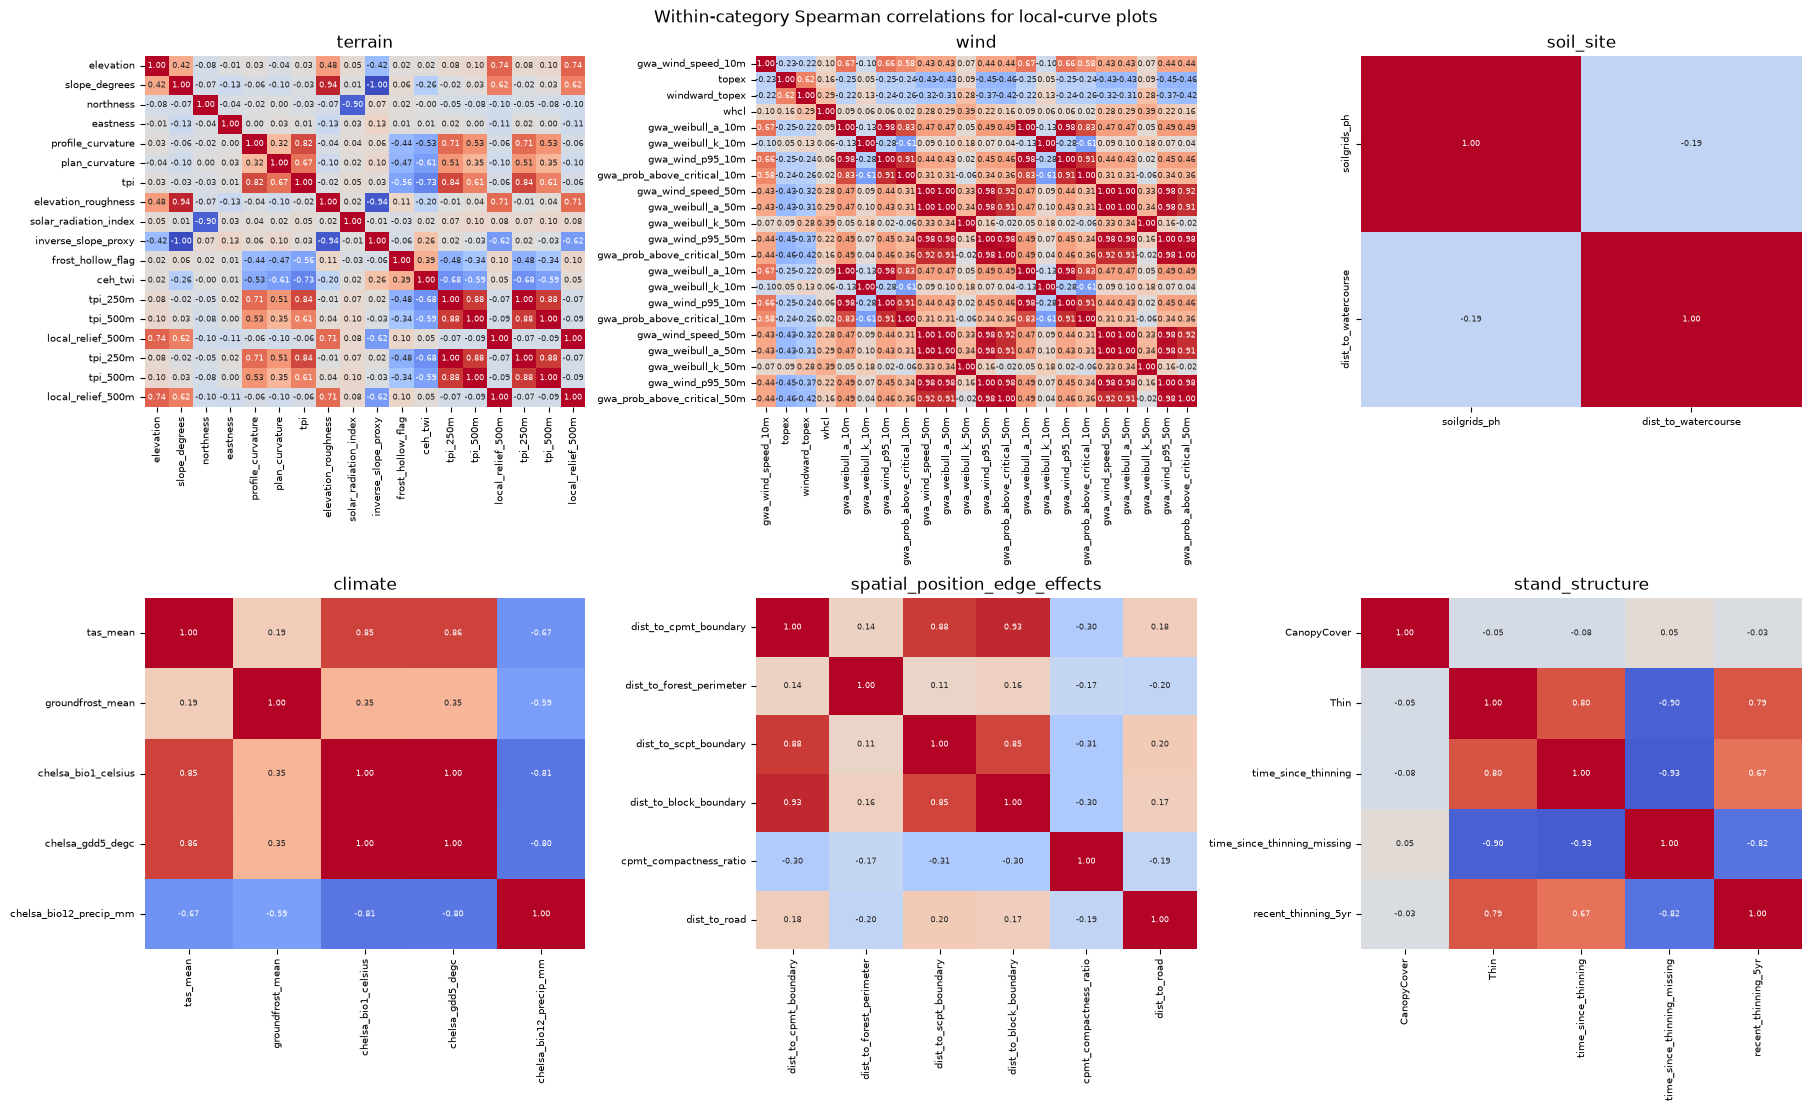

,category_a,variable_a,category_b,variable_b,rho,p_value
92,terrain,elevation,climate,chelsa_gdd5_degc,-0.948110,0.0
91,terrain,elevation,climate,chelsa_bio1_celsius,-0.945837,0.0
89,terrain,elevation,climate,tas_mean,-0.887676,0.0
93,terrain,elevation,climate,chelsa_bio12_precip_mm,0.809803,0.0
47,terrain,tpi_500m,wind,topex,-0.780617,0.0
67,terrain,tpi_500m,wind,topex,-0.780617,0.0
111,terrain,local_relief_500m,climate,chelsa_bio1_celsius,-0.759833,0.0
106,terrain,local_relief_500m,climate,chelsa_bio1_celsius,-0.759833,0.0
12,terrain,elevation,wind,gwa_weibull_a_50m,0.757928,0.0
5,terrain,elevation,wind,gwa_weibull_a_50m,0.757928,0.0


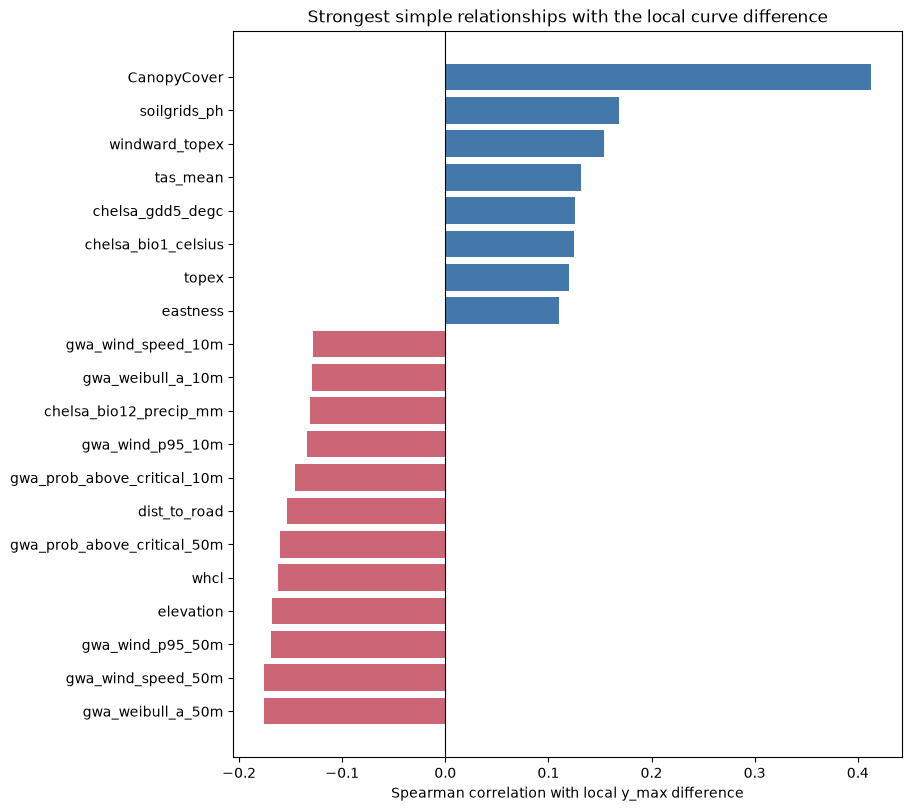

In [12]:
heatmap_groups = {}
for category, columns in LOCAL_CATEGORY_GROUPS.items():
    valid_columns = [column for column in columns if column in local_plots and column not in CATEGORICAL_COLUMNS]
    if len(valid_columns) >= 2:
        heatmap_groups[category] = valid_columns

fig, axes = plt.subplots(2, 3, figsize=(18, 11), constrained_layout=True)
for ax, (category, columns) in zip(axes.ravel(), heatmap_groups.items()):
    correlation = local_plots[columns].corr(method='spearman')
    sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, cbar=False, ax=ax, annot_kws={'size':6})
    ax.set_title(category)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(heatmap_groups):]:
    ax.axis('off')
fig.suptitle('Within-category Spearman correlations for local-curve plots')
plt.show()

cross_groups = {category:[column for column in columns if column in local_plots.columns and column not in CATEGORICAL_COLUMNS] for category, columns in LOCAL_CATEGORY_GROUPS.items()}
cross_category = cross_category_correlations(local_plots, category_groups=cross_groups, threshold=.30)
display(cross_category.head(30))

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
top_target = target_correlations.head(20).sort_values('spearman_rho')
ax.barh(top_target['variable'], top_target['spearman_rho'], color=np.where(top_target['spearman_rho']>=0, '#4477aa', '#cc6677'))
ax.axvline(0, color='black', linewidth=.8)
ax.set_xlabel('Spearman correlation with local y_max difference')
ax.set_title('Strongest simple relationships with the local curve difference')
plt.show()


## 9. Compare plot and subcompartment support

The subcompartment quantity is the median of its plot-level curve differences. This avoids fitting
one curve across plots that may carry different recorded `p4` and `p5` values. Environmental
continuous variables use medians. Categorical variables use the modal class.

Subcompartments with few plots remain visible. They are not silently treated as precise summaries.


,n_plots,target_iqr,local_y_max_difference
count,589.000000,589.000000,589.000000
mean,96.504244,8.290372,4.123013
std,133.367589,4.834112,10.543087
min,1.000000,0.000000,-37.125122
25%,13.000000,5.195890,-1.684509
50%,42.000000,7.452468,4.411211
75%,120.000000,10.308312,10.810646
max,747.000000,44.460418,31.750048


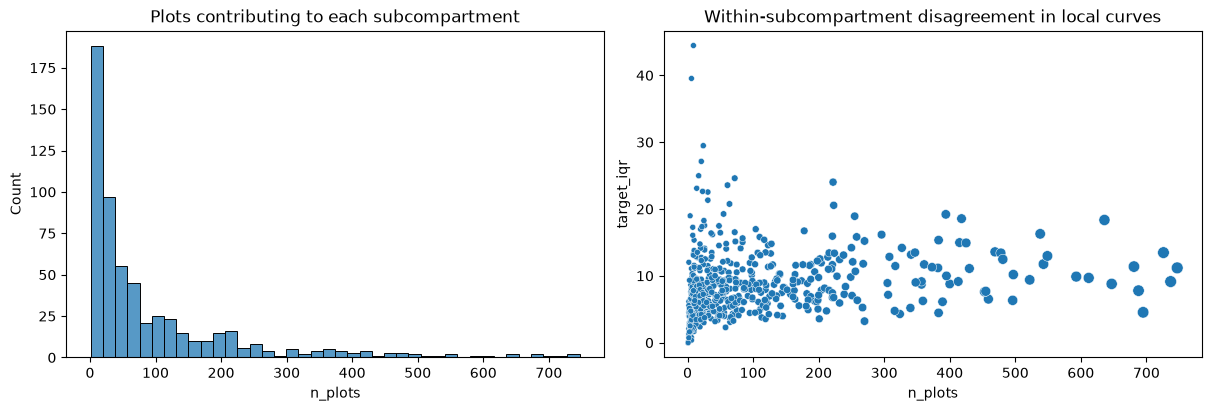

In [13]:
group_keys = ['cpmt', 'scpt']
categorical_features = [column for column in CATEGORICAL_COLUMNS if column in available_features]
continuous_aggregation = {column: 'median' for column in continuous_features}
area_table = local_plots.groupby(group_keys).agg(
    n_plots=('identification','nunique'), x=('x','mean'), y=('y','mean'),
    local_y_max_difference=(TARGET,'median'), target_iqr=(TARGET, lambda values: values.quantile(.75)-values.quantile(.25)),
    **{column: (column, method) for column, method in continuous_aggregation.items()},
).reset_index()
area_table['identification'] = area_table['cpmt'].astype(str) + '::' + area_table['scpt'].astype(str)
for column in categorical_features:
    modes = local_plots.groupby(group_keys)[column].agg(lambda values: values.mode().iloc[0] if not values.mode().empty else np.nan)
    area_table = area_table.merge(modes.rename(column).reset_index(), on=group_keys, how='left')

display(area_table[['n_plots','target_iqr',TARGET]].describe())
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
sns.histplot(area_table['n_plots'], bins=40, ax=axes[0])
axes[0].set_title('Plots contributing to each subcompartment')
sns.scatterplot(data=area_table, x='n_plots', y='target_iqr', size='n_plots', legend=False, ax=axes[1])
axes[1].set_title('Within-subcompartment disagreement in local curves')
plt.show()


## 10. Map the subcompartment summaries

Points are drawn at subcompartment mean coordinates because this table does not contain polygon
geometry. Point size shows how many plots contribute. Large symbols are more stable summaries;
single-plot subcompartments are not genuine aggregation.


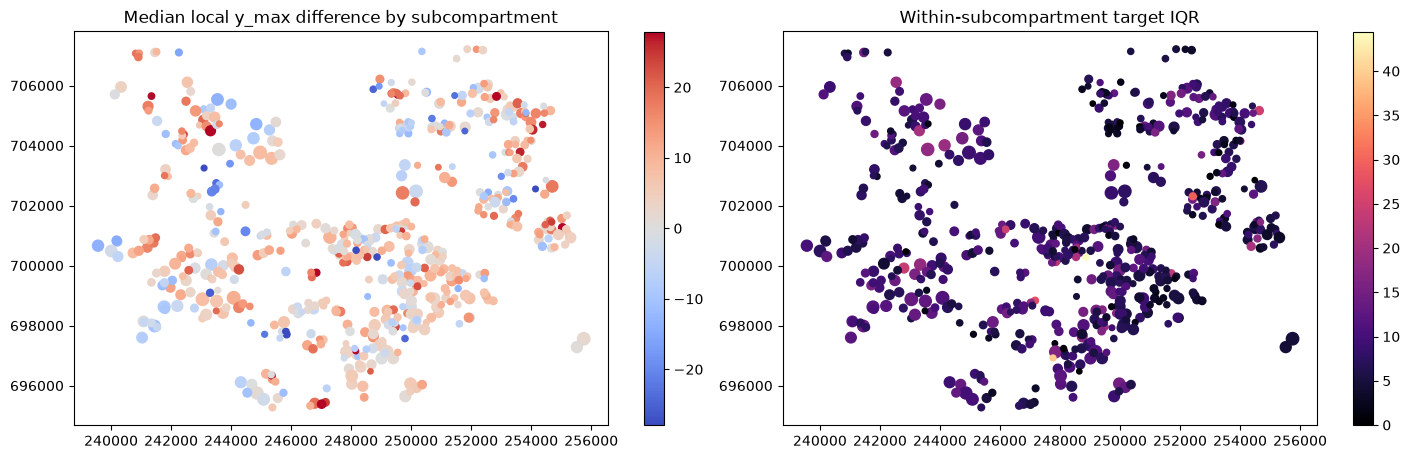

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
limit = np.nanquantile(np.abs(area_table[TARGET]), .98)
sizes = 12 + 70*np.sqrt(area_table['n_plots']/area_table['n_plots'].max())
mapped = axes[0].scatter(area_table['x'], area_table['y'], c=area_table[TARGET], s=sizes, cmap='coolwarm', vmin=-limit, vmax=limit)
axes[0].set_title('Median local y_max difference by subcompartment')
fig.colorbar(mapped, ax=axes[0], shrink=.8)
uncertainty = axes[1].scatter(area_table['x'], area_table['y'], c=area_table['target_iqr'], s=sizes, cmap='magma')
axes[1].set_title('Within-subcompartment target IQR')
fig.colorbar(uncertainty, ax=axes[1], shrink=.8)
for ax in axes:
    ax.set_aspect('equal')
plt.show()


## 11. Spatially held-out attribution screen

This reuses Elastic Net and XGBoost as statistical attribution tools. It does not build the new
DNN, PINN, GNNWR or hierarchical model. Compartments are kept in one split. The final test set
remains locked because the data-quality rule, variable set and plot-versus-subcompartment choice
have not been fixed yet.

Validation checks whether an apparent environmental explanation transfers to unseen
compartments instead of reflecting spatial overfit. R² is read as held-out variation associated
with the variables, not as a goal to force the yldc difference towards zero.


In [15]:
# Deterministic transforms are mapped and audited, but are not entered together in the headline
# multivariable screen. A separate representation comparison below tests them fairly.
main_screen_exclusions = {
    'inverse_slope_proxy',
    'gwa_wind_speed_10m', 'gwa_weibull_a_10m', 'gwa_weibull_k_10m',
    'gwa_wind_p95_10m', 'gwa_prob_above_critical_10m',
    'gwa_wind_speed_50m', 'gwa_wind_p95_50m', 'gwa_prob_above_critical_50m',
}
screen_features = [column for column in available_features if column not in main_screen_exclusions]

def run_validation_screen(table, scale_name):
    table = table.copy()
    split_coordinates = table[['identification', 'x', 'y']].copy()
    table['split'] = spatial_block_split(
        table, block_col=SPATIAL_BLOCK_COL, buffer_distance=SPATIAL_BUFFER_METRES,
        coordinates_df=split_coordinates, seed=42,
    )
    train = drop_rows_with_missing_features(table[table['split']=='train'], screen_features)
    val = drop_rows_with_missing_features(table[table['split']=='val'], screen_features)
    test = table[table['split']=='test']  # deliberately not evaluated in this notebook

    elastic = elasticnet_fit(train, screen_features, target_col=TARGET)
    elastic_pred = elasticnet_predict(val, elastic, screen_features)
    elastic_metrics = compute_metrics(val[TARGET], elastic_pred)

    tree = xgb_fit(train, screen_features, val_df=val, target_col=TARGET, n_estimators=500, max_depth=4, learning_rate=0.04)
    tree_pred = xgb_predict(val, tree, screen_features)
    tree_metrics = compute_metrics(val[TARGET], tree_pred)

    permutation_rows = []
    for category, columns in LOCAL_CATEGORY_GROUPS.items():
        present = [column for column in columns if column in screen_features]
        result = grouped_permutation_importance(tree, val, screen_features, present, xgb_predict, target_col=TARGET, n_repeats=20)
        permutation_rows.append({'category': category, **result})

    metrics = pd.DataFrame([
        {'scale': scale_name, 'method': 'Elastic Net', **elastic_metrics},
        {'scale': scale_name, 'method': 'XGBoost', **tree_metrics},
    ])
    return metrics, pd.DataFrame(permutation_rows).sort_values('mean_r2_drop', ascending=False), {'train':len(train),'val':len(val),'test_locked':len(test)}

plot_metrics, plot_groups, plot_counts = run_validation_screen(local_plots, 'plot')
area_metrics, area_groups, area_counts = run_validation_screen(area_table, 'subcompartment median')
display(pd.concat([plot_metrics, area_metrics], ignore_index=True))
print('Plot split counts:', plot_counts)
print('Subcompartment split counts:', area_counts)
display(plot_groups)
display(area_groups)


  Buffer: 2,117 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.
  Dropped 243 of 31635 rows with a missing value in one of 40 features
  Dropped 94 of 11517 rows with a missing value in one of 40 features
  Buffer: 1 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.
  Dropped 2 of 350 rows with a missing value in one of 40 features
  Dropped 3 of 118 rows with a missing value in one of 40 features


,scale,method,n,mae,mse,rmse,r2,mre,accuracy_pct,bias
0,plot,Elastic Net,11423,7.483763,90.670327,9.522097,0.374263,4.059369,-305.936933,-0.578319
1,plot,XGBoost,11423,8.116950,102.773677,10.137735,0.290735,4.372426,-337.242627,-0.320791
2,subcompartment median,Elastic Net,115,7.413761,94.945649,9.744006,0.274872,3.955870,-295.586984,-0.989776
3,subcompartment median,XGBoost,115,6.986876,88.260580,9.394710,0.325928,3.696153,-269.615320,-0.768177


Plot split counts: {'train': 31392, 'val': 11423, 'test_locked': 11572}
Subcompartment split counts: {'train': 348, 'val': 115, 'test_locked': 120}


,category,baseline_r2,mean_r2_drop,std_r2_drop,n_repeats
5,stand_structure,0.290735,0.361151,0.007385,20
0,terrain,0.290735,0.113228,0.002131,20
3,climate,0.290735,0.041993,0.003715,20
4,spatial_position_edge_effects,0.290735,0.024032,0.001269,20
1,wind,0.290735,0.022343,0.001016,20
2,soil_site,0.290735,-0.002768,0.000671,20


,category,baseline_r2,mean_r2_drop,std_r2_drop,n_repeats
5,stand_structure,0.325928,0.611020,0.101514,20
0,terrain,0.325928,0.060472,0.032274,20
4,spatial_position_edge_effects,0.325928,0.023040,0.011126,20
1,wind,0.325928,0.005949,0.008637,20
2,soil_site,0.325928,-0.007115,0.003595,20
3,climate,0.325928,-0.012290,0.019135,20


## Compare alternative wind and terrain representations

GWA mean wind, Weibull A, p95 and exceedance probability are mathematically related. Putting all
of them in one model cannot show which representation is genuinely most useful. This section adds
one pre-defined representation at a time to the same non-wind environmental baseline. It reports
the change in spatial-validation R². The same method compares the new terrain scales.

The comparison tests association with the local curve difference. It does not treat a larger R²
as evidence that the variable caused growth or that the yldc difference should be eliminated.


In [16]:
representation_table = local_plots.copy()
representation_coordinates = representation_table[['identification','x','y']]
representation_table['split'] = spatial_block_split(
    representation_table, block_col=SPATIAL_BLOCK_COL, buffer_distance=SPATIAL_BUFFER_METRES,
    coordinates_df=representation_coordinates, seed=42,
)
representation_train = representation_table[representation_table['split']=='train']
representation_val = representation_table[representation_table['split']=='val']

stand_set = set(LOCAL_CATEGORY_GROUPS['stand_structure'])
wind_set = set(LOCAL_CATEGORY_GROUPS['wind'])
base_without_wind = [
    column for column in available_features
    if column not in stand_set and column not in wind_set and column != 'inverse_slope_proxy'
]
wind_representations = {
    'no wind variables': [],
    'local shelter only': ['topex','windward_topex','whcl'],
    'GWA mean wind at 10 m (flagged within-canopy comparison)': ['gwa_wind_speed_10m'],
    'GWA mean wind at 50 m': ['gwa_wind_speed_50m'],
    'GWA Weibull A+k at 50 m': ['gwa_weibull_a_50m','gwa_weibull_k_50m'],
    'GWA p95+k at 50 m': ['gwa_wind_p95_50m','gwa_weibull_k_50m'],
    'GWA probability above 20 m/s at 50 m': ['gwa_prob_above_critical_50m'],
    'local shelter plus GWA A+k at 50 m': ['topex','windward_topex','whcl','gwa_weibull_a_50m','gwa_weibull_k_50m'],
}

def compare_representations(representations, base_columns, family):
    rows = []
    for representation, added_columns in representations.items():
        columns = list(dict.fromkeys(base_columns + [column for column in added_columns if column in local_plots]))
        train = drop_rows_with_missing_features(representation_train, columns)
        val = drop_rows_with_missing_features(representation_val, columns)
        for method, fitted, predictions in [
            ('Elastic Net', elasticnet_fit(train, columns, target_col=TARGET), None),
            ('XGBoost', xgb_fit(train, columns, val_df=val, target_col=TARGET, n_estimators=500, max_depth=4, learning_rate=.04), None),
        ]:
            if method == 'Elastic Net':
                predicted = elasticnet_predict(val, fitted, columns)
            else:
                predicted = xgb_predict(val, fitted, columns)
            metrics = compute_metrics(val[TARGET], predicted)
            rows.append({'family':family, 'representation':representation, 'method':method, 'n_features':len(columns), **metrics})
    result = pd.DataFrame(rows)
    for method in result['method'].unique():
        baseline = result[(result['method']==method) & (result['representation'].str.startswith('no '))]['r2'].iloc[0]
        result.loc[result['method']==method, 'r2_change_from_family_baseline'] = result.loc[result['method']==method, 'r2'] - baseline
    return result

wind_comparison = compare_representations(wind_representations, base_without_wind, 'wind')
display(wind_comparison[['representation','method','n','r2','r2_change_from_family_baseline','rmse','bias']])

new_terrain_columns = ['tpi_250m','tpi_500m','local_relief_500m']
terrain_base = [column for column in base_without_wind if column not in new_terrain_columns]
terrain_representations = {
    'no new multiscale terrain': [],
    'TPI 250 m': ['tpi_250m'],
    'TPI 500 m': ['tpi_500m'],
    'local relief 500 m': ['local_relief_500m'],
    'TPI 250 m plus local relief 500 m': ['tpi_250m','local_relief_500m'],
    'all new multiscale terrain': new_terrain_columns,
}
terrain_comparison = compare_representations(terrain_representations, terrain_base, 'terrain')
display(terrain_comparison[['representation','method','n','r2','r2_change_from_family_baseline','rmse','bias']])


  Buffer: 2,117 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.
  Dropped 243 of 31635 rows with a missing value in one of 30 features
  Dropped 94 of 11517 rows with a missing value in one of 30 features
  Dropped 243 of 31635 rows with a missing value in one of 33 features
  Dropped 94 of 11517 rows with a missing value in one of 33 features
  Dropped 243 of 31635 rows with a missing value in one of 31 features
  Dropped 94 of 11517 rows with a missing value in one of 31 features
  Dropped 243 of 31635 rows with a missing value in one of 31 features
  Dropped 94 of 11517 rows with a missing value in one of 31 features
  Dropped 243 of 31635 rows with a missing value in one of 32 features
  Dropped 94 of 11517 rows with a missing value in one of 32 features
  Dropped 243 of 31635 rows with a missing value in one of 32 features
  Dropped 94 of 11517 rows with a missing value in one of 32 features
  Dropped 243 of 31635 rows 

,representation,method,n,r2,r2_change_from_family_baseline,rmse,bias
0,no wind variables,Elastic Net,11423,0.136905,0.000000,11.183199,0.056638
1,no wind variables,XGBoost,11423,0.054904,0.000000,11.702393,1.067423
2,local shelter only,Elastic Net,11423,0.168529,0.031624,10.976408,0.205470
3,local shelter only,XGBoost,11423,0.058142,0.003238,11.682331,0.990799
4,GWA mean wind at 10 m (flagged within-canopy c...,Elastic Net,11423,0.142179,0.005274,11.148978,0.149263
5,GWA mean wind at 10 m (flagged within-canopy c...,XGBoost,11423,0.062283,0.007379,11.656619,1.067162
6,GWA mean wind at 50 m,Elastic Net,11423,0.141933,0.005028,11.150575,0.053062
7,GWA mean wind at 50 m,XGBoost,11423,0.054504,-0.000400,11.704870,1.064806
8,GWA Weibull A+k at 50 m,Elastic Net,11423,0.142508,0.005603,11.146843,0.035273
9,GWA Weibull A+k at 50 m,XGBoost,11423,0.054112,-0.000792,11.707294,1.062571


  Dropped 243 of 31635 rows with a missing value in one of 27 features
  Dropped 94 of 11517 rows with a missing value in one of 27 features
  Dropped 243 of 31635 rows with a missing value in one of 28 features
  Dropped 94 of 11517 rows with a missing value in one of 28 features
  Dropped 243 of 31635 rows with a missing value in one of 28 features
  Dropped 94 of 11517 rows with a missing value in one of 28 features
  Dropped 243 of 31635 rows with a missing value in one of 28 features
  Dropped 94 of 11517 rows with a missing value in one of 28 features
  Dropped 243 of 31635 rows with a missing value in one of 29 features
  Dropped 94 of 11517 rows with a missing value in one of 29 features
  Dropped 243 of 31635 rows with a missing value in one of 30 features
  Dropped 94 of 11517 rows with a missing value in one of 30 features


,representation,method,n,r2,r2_change_from_family_baseline,rmse,bias
0,no new multiscale terrain,Elastic Net,11423,0.130831,0.000000,11.222482,0.100323
1,no new multiscale terrain,XGBoost,11423,0.053096,0.000000,11.713583,1.011168
2,TPI 250 m,Elastic Net,11423,0.139775,0.008944,11.164592,0.068733
3,TPI 250 m,XGBoost,11423,0.052329,-0.000767,11.718326,1.082321
4,TPI 500 m,Elastic Net,11423,0.143010,0.012179,11.143580,0.115287
5,TPI 500 m,XGBoost,11423,0.051525,-0.001571,11.723293,1.111286
6,local relief 500 m,Elastic Net,11423,0.136917,0.006086,11.183123,0.056552
7,local relief 500 m,XGBoost,11423,0.049404,-0.003692,11.736397,1.097738
8,TPI 250 m plus local relief 500 m,Elastic Net,11423,0.136917,0.006086,11.183123,0.056552
9,TPI 250 m plus local relief 500 m,XGBoost,11423,0.053112,0.000016,11.713485,1.000269


### First spatial-validation result for the added candidates

These values come from the executable comparison immediately above. They use validation
compartments only; the test set remains locked.

- The non-wind environmental Elastic Net baseline had R²=0.137. Local shelter
  (`TOPEX + windward TOPEX + WHCL`) increased it to 0.169. This was the strongest wind
  representation tested.
- GWA 50 m mean wind produced R²=0.142. GWA 50 m Weibull A+k produced R²=0.143. They add a
  small amount of transferable information, but less than local terrain shelter.
- Derived GWA p95+k produced R²=0.134 and probability above 20 m/s produced R²=0.136. Neither
  improves this linear validation result.
- Mean wind, Weibull A, p95 and exceedance probability are extremely redundant at 50 m
  (absolute Spearman correlations approximately 0.91-1.00 for most pairs). Keep one regime
  representation plus `k_w`; do not interpret them as independent drivers.
- The no-new-terrain Elastic Net baseline had R²=0.131. TPI at 250 m increased it to 0.140;
  TPI at 500 m increased it to 0.143. Local relief increased it to 0.137. Adding all three
  together returned R²=0.137 because the TPI scales are correlated.
- XGBoost did not gain materially from these additions. Its validation R² stayed near
  0.05-0.06. The current associations are more stable in the regularised linear screen.

The most useful provisional additions are 500 m TPI and crown-level GWA A+k, but local shelter
remains more informative than GWA alone. These are associations with the local curve difference,
not evidence that wind or terrain caused it.

### Resolution rule used here

There is no defensible universal pixel-size cutoff. The working GIS rule is: retain 20-50 m
terrain, roughly 100-250 m wind-regime surfaces, and 1 km climate only for broad exposure. A
candidate should normally provide at least 20-30 independent spatial support units across the
forest. Fewer than about 10 cells is too coarse for attributing differences between areas, even
if the raster is resampled to every plot. Station weather retains its hourly timing, but station
distance and coverage must be reported because its spatial support is not plot-scale.


## 12. Detailed attribution diagnostics for the local curve difference

The maps below use validation plots only. The model never sees their target during fitting. The
environment-only model is shown because it answers the ecological question without canopy cover
and thinning dominating the result. SHAP describes what this fitted tree used; it is not a causal
test. Refit ablation is the stronger check of unique explanatory contribution.


In [17]:
diagnostic_table = local_plots.copy()
diagnostic_coordinates = diagnostic_table[['identification','x','y']]
diagnostic_table['split'] = spatial_block_split(
    diagnostic_table, block_col=SPATIAL_BLOCK_COL, buffer_distance=SPATIAL_BUFFER_METRES,
    coordinates_df=diagnostic_coordinates, seed=42,
)
environment_columns = nested_feature_sets['environment without stand structure']
diagnostic_train = drop_rows_with_missing_features(diagnostic_table[diagnostic_table['split']=='train'], environment_columns)
diagnostic_val = drop_rows_with_missing_features(diagnostic_table[diagnostic_table['split']=='val'], environment_columns).copy()
diagnostic_model = xgb_fit(
    diagnostic_train, environment_columns, val_df=diagnostic_val, target_col=TARGET,
    n_estimators=500, max_depth=4, learning_rate=.04,
)
diagnostic_val['environment_associated_component'] = xgb_predict(diagnostic_val, diagnostic_model, environment_columns)
diagnostic_val['remaining_curve_difference'] = diagnostic_val[TARGET] - diagnostic_val['environment_associated_component']

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
for ax, column, title in [
    (axes[0], TARGET, 'Observed local curve difference'),
    (axes[1], 'environment_associated_component', 'Component associated with environment'),
    (axes[2], 'remaining_curve_difference', 'Curve difference not associated by this model'),
]:
    plotted = plot_spatial_values(ax, diagnostic_val, column, title, symmetric=True)
    fig.colorbar(plotted, ax=ax, shrink=.78)
plt.show()

shap_sample = diagnostic_val.sample(n=min(4000, len(diagnostic_val)), random_state=42)
explainer = shap.TreeExplainer(diagnostic_model)
shap_values = explainer.shap_values(shap_sample[environment_columns])
shap.summary_plot(shap_values, shap_sample[environment_columns], max_display=15, show=False)
plt.title('Environment-only XGBoost SHAP on spatial validation plots')
plt.tight_layout()
plt.show()


  Buffer: 2,117 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


NameError: name 'nested_feature_sets' is not defined

In [ ]:
environment_categories = {
    category:[column for column in columns if column in environment_columns]
    for category, columns in LOCAL_CATEGORY_GROUPS.items() if category != 'stand_structure'
}
environment_categories = {category:columns for category, columns in environment_categories.items() if columns}

variable_ablation = per_variable_refit_ablation(
    diagnostic_train, diagnostic_val, environment_columns, xgb_fit, xgb_predict, target_col=TARGET,
)
display(variable_ablation.sort_values('r2_drop', ascending=False))

spatial_ablation = category_morans_i_before_after(
    diagnostic_train, diagnostic_val, xgb_fit, xgb_predict,
    all_columns=environment_columns, category_groups=environment_categories, target_col=TARGET,
)
display(spatial_ablation)
print("Interpret R2, RMSE, remainder maps and Moran's I together; lower Moran's I alone does not mean stronger explanation.")


## 13. Isolate the environmental question from contemporaneous stand structure

Canopy cover and thinning variables can explain a local curve without identifying an
environmental cause. Canopy cover is measured from the same LiDAR surveys as top height. It may
describe current stand condition, disturbance or the same sensing process. The nested screen
below reports three different questions rather than mixing them:

- all available variables: broad descriptive association;
- environment without stand structure: environmental attribution;
- terrain and wind only: the narrow question from the original project.

The zero baseline is also shown. It represents assuming that the recorded yldc curve has no
systematic local difference. Its poor performance is expected and is not the outcome being
optimised. The training mean is the ordinary no-variable comparison.


In [ ]:
stand_columns = set(LOCAL_CATEGORY_GROUPS['stand_structure'])
terrain_wind_columns = [
    column for category in ['terrain','wind']
    for column in LOCAL_CATEGORY_GROUPS[category]
    if column in screen_features
]
nested_feature_sets = {
    'all variables': screen_features,
    'environment without stand structure': [column for column in screen_features if column not in stand_columns],
    'terrain and wind only': terrain_wind_columns,
}

def nested_validation(table, scale_name):
    table = table.copy()
    coordinates = table[['identification','x','y']].copy()
    table['split'] = spatial_block_split(
        table, block_col=SPATIAL_BLOCK_COL, buffer_distance=SPATIAL_BUFFER_METRES,
        coordinates_df=coordinates, seed=42,
    )
    rows = []
    train_unfiltered = table[table['split']=='train']
    val_unfiltered = table[table['split']=='val']
    baseline_mean = train_unfiltered[TARGET].mean()
    for baseline_name, prediction in [('recorded yldc (zero adjustment)', 0.0), ('training mean', baseline_mean)]:
        metrics = compute_metrics(val_unfiltered[TARGET], np.full(len(val_unfiltered), prediction))
        rows.append({'scale':scale_name, 'feature_set':baseline_name, 'method':'baseline', **metrics})
    for feature_set_name, columns in nested_feature_sets.items():
        train = drop_rows_with_missing_features(train_unfiltered, columns)
        val = drop_rows_with_missing_features(val_unfiltered, columns)
        elastic = elasticnet_fit(train, columns, target_col=TARGET)
        elastic_predictions = elasticnet_predict(val, elastic, columns)
        elastic_metrics = compute_metrics(val[TARGET], elastic_predictions)
        rows.append({'scale':scale_name, 'feature_set':feature_set_name, 'method':'Elastic Net', **elastic_metrics})

        tree = xgb_fit(
            train, columns, val_df=val, target_col=TARGET, n_estimators=500,
            max_depth=4, learning_rate=0.04,
        )
        tree_predictions = xgb_predict(val, tree, columns)
        tree_metrics = compute_metrics(val[TARGET], tree_predictions)
        rows.append({'scale':scale_name, 'feature_set':feature_set_name, 'method':'XGBoost', **tree_metrics})
    return pd.DataFrame(rows)

nested_results = pd.concat([
    nested_validation(local_plots, 'plot'),
    nested_validation(area_table, 'subcompartment median'),
], ignore_index=True)
display(nested_results[['scale','feature_set','method','n','r2','rmse','mae','bias']])


## 14. Observed storms between surveys (primary extension)

Static wind and terrain describe persistent exposure. MIDAS station observations describe what
happened between two LiDAR surveys. The interval metrics are maximum gust, gust p95, mean-wind
p95, hours above a fixed gust threshold, cumulative gust excess, independent storm count and
time since the last threshold-exceeding storm.

A station is not plot-scale wind data. Results must show station distance and observation
coverage. The default analysis compares 20, 25 and 30 m/s gust thresholds and separates storms
by 48 hours. This is a sensitivity analysis, not a claim that one threshold is a universal tree
failure speed. Run `data_processing/build_midas_wind_intervals.py` after downloading the nearest
quality-controlled MIDAS Open station files from CEDA.


In [ ]:
MIDAS_INTERVAL_PATH = project_root / 'data/processed/environmental/midas_wind_interval_metrics.parquet'
MIDAS_EVENT_PATH = project_root / 'data/processed/environmental/aberfoyle_storm_events.csv'
if MIDAS_INTERVAL_PATH.exists():
    midas_intervals = pd.read_parquet(MIDAS_INTERVAL_PATH)
    storm_events = pd.read_csv(MIDAS_EVENT_PATH, parse_dates=['event_start','event_end'])
    coverage = (midas_intervals.groupby('midas_station_id', as_index=False)
                .agg(mean_coverage=('midas_observation_coverage','mean'),
                     minimum_coverage=('midas_observation_coverage','min'),
                     distance_km=('station_distance_km','first'),
                     station_name=('station_name','first'),
                     intervals=('LiDAR_year','nunique')))
    display(coverage.sort_values(['distance_km']))
else:
    midas_intervals = pd.DataFrame()
    storm_events = pd.DataFrame()
    print('MIDAS interval file is not present. The cells below do not invent storm values.')


In [ ]:
if not midas_intervals.empty:
    eligible_stations = coverage.loc[coverage['minimum_coverage'] >= .75].sort_values('distance_km')
    selected_station = eligible_stations.iloc[0]['midas_station_id']
    selected_threshold = 25.0
    interval_wind = midas_intervals.loc[
        (midas_intervals['midas_station_id'] == selected_station) &
        np.isclose(midas_intervals['midas_gust_threshold_ms'], selected_threshold)
    ].copy()
    wind_plot_columns = ['midas_max_gust_ms','midas_cumulative_gust_excess_per_year',
                         'midas_independent_storm_count_per_year','midas_time_since_last_major_storm_days']
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
    interval_wind['interval'] = (interval_wind['previous_lidar_year'].astype(str) + '–' +
                                 interval_wind['LiDAR_year'].astype(str))
    for ax, column in zip(axes.ravel(), wind_plot_columns):
        sns.barplot(data=interval_wind, x='interval', y=column, ax=ax, color='#4477AA')
        ax.tick_params(axis='x', rotation=45)
        ax.set_title(column.replace('midas_', '').replace('_', ' '))
    fig.suptitle(f'Observed wind between surveys: station {selected_station}, threshold {selected_threshold:g} m/s')
    plt.show()


In [ ]:
if not midas_intervals.empty:
    transition_frames = []
    for cohort in ['4survey', '6survey']:
        path = project_root / f'data/processed/transitions/transition_growth_{cohort}.parquet'
        frame = pd.read_parquet(path)
        frame['cohort'] = cohort
        transition_frames.append(frame)
    transitions = pd.concat(transition_frames, ignore_index=True)
    wind_columns = ['previous_lidar_year','LiDAR_year','midas_max_gust_ms','midas_gust_p95_ms',
                    'midas_mean_wind_p95_ms','midas_hours_above_critical',
                    'midas_cumulative_gust_excess_ms_hours','midas_cumulative_gust_excess_per_year',
                    'midas_independent_storm_count','midas_independent_storm_count_per_year',
                    'midas_time_since_last_major_storm_days','midas_observation_coverage']
    transition_wind = transitions.merge(interval_wind[wind_columns],
                                        on=['previous_lidar_year','LiDAR_year'], how='left')
    outcomes = ['annual_height_increment','height_increment','canopy_change']
    exposures = [column for column in wind_columns if column.startswith('midas_') and
                 column != 'midas_observation_coverage']
    reliable = transition_wind.loc[transition_wind['midas_observation_coverage'] >= 0.75]
    # Regional station exposure repeats for every plot in an interval. Aggregate first;
    # treating repeated plots as independent storm observations would be pseudoreplication.
    interval_outcomes = (reliable.groupby(['previous_lidar_year','LiDAR_year'], as_index=False)
                         .agg(**{f'{column}_median':(column,'median') for column in outcomes}))
    interval_analysis = interval_outcomes.merge(interval_wind[wind_columns],
                                                on=['previous_lidar_year','LiDAR_year'], how='left')
    outcome_medians = [f'{column}_median' for column in outcomes]
    association = interval_analysis[outcome_medians + exposures].corr(method='spearman').loc[outcome_medians, exposures]
    display(association.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format('{:.2f}'))
    print(f'Descriptive interval correlations use only {len(interval_analysis)} survey intervals; do not interpret p-values or causation.')
    threshold_sensitivity = (midas_intervals.loc[midas_intervals['midas_station_id'] == selected_station]
        .groupby('midas_gust_threshold_ms', as_index=False)
        .agg(mean_storms=('midas_independent_storm_count','mean'),
             total_excess=('midas_cumulative_gust_excess_ms_hours','sum'),
             minimum_coverage=('midas_observation_coverage','min')))
    display(threshold_sensitivity)


## 15. Decision rules before a final attribution model

Do not choose the analysis scale from validation R² alone. Prefer plot-level targets only if
fixed-shape curve error is acceptable and results are stable after flagged trajectories are
reviewed. Prefer subcompartments if plot parameters are noisy and each subcompartment contains
enough plots, but report the lost within-area variation.

A variable is a strong candidate only when it:

1. passes source, resolution, coverage and map checks;
2. is not an exact or avoidable duplicate;
3. contributes stable explanatory information in spatially held-out areas;
4. remains useful across spatial splits and both cohorts;
5. has a stable relationship after extreme trajectories are reviewed; and
6. has a plausible interpretation that does not rely on treating association as causation.

Static terrain, soil and long-term wind belong in this curve-level analysis. Storms, droughts
and thinning events require a second interval-level analysis of deviations around the local
curve. They should not be averaged into a permanent curve parameter.
